In [2]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

RANDOM_STATE = 42

# Load the trained Random Forest models from Task 2
with open('../models/rf_fraud.pkl', 'rb') as f:
    rf_f = pickle.load(f)

with open('../models/rf_credit.pkl', 'rb') as f:
    rf_c = pickle.load(f)

print("Models loaded.")

c:\Users\HP EliteBook\Desktop\KAIM\fraud-detection\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Models loaded.


In [6]:
from sklearn.model_selection import train_test_split

fraud_df = pd.read_csv('../data/processed/fraud_data_processed.csv')
credit_df = pd.read_csv('../data/processed/creditcard_processed.csv')

# ── Fraud data ──
TARGET_FRAUD = 'class'
drop_cols_fraud = [TARGET_FRAUD, 'user_id', 'device_id', 'ip_address',
                   'signup_time', 'purchase_time', 'lower_int', 'upper_int']
drop_cols_fraud = [c for c in drop_cols_fraud if c in fraud_df.columns]

X_fraud = fraud_df.drop(columns=drop_cols_fraud)
y_fraud = fraud_df[TARGET_FRAUD]

X_train_f, X_test_f, y_train_f, y_test_f = train_test_split(
    X_fraud, y_fraud, test_size=0.2, stratify=y_fraud, random_state=RANDOM_STATE
)

# ── Credit card data ──
TARGET_CREDIT = 'Class'
X_credit = credit_df.drop(columns=[TARGET_CREDIT])
y_credit = credit_df[TARGET_CREDIT]

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_credit, y_credit, test_size=0.2, stratify=y_credit, random_state=RANDOM_STATE
)

print("Fraud test shape:", X_test_f.shape)
print("Credit test shape:", X_test_c.shape)

Fraud test shape: (30223, 196)
Credit test shape: (56746, 32)


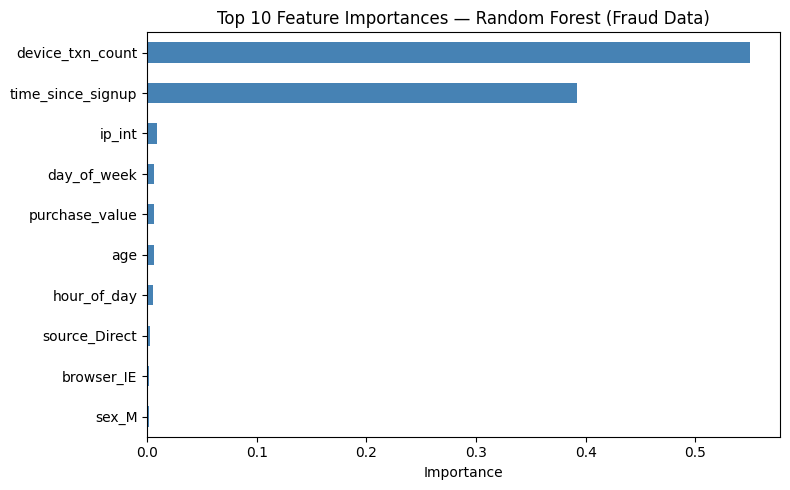

device_txn_count     0.549685
time_since_signup    0.391891
ip_int               0.008618
day_of_week          0.006626
purchase_value       0.005914
age                  0.005822
hour_of_day          0.005258
source_Direct        0.002899
browser_IE           0.001644
sex_M                0.001590
dtype: float64


In [7]:
importances_f = pd.Series(rf_f.feature_importances_, index=X_train_f.columns)
top10_f = importances_f.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10_f.sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 10 Feature Importances — Random Forest (Fraud Data)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../notebooks/feature_importance_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

print(top10_f)

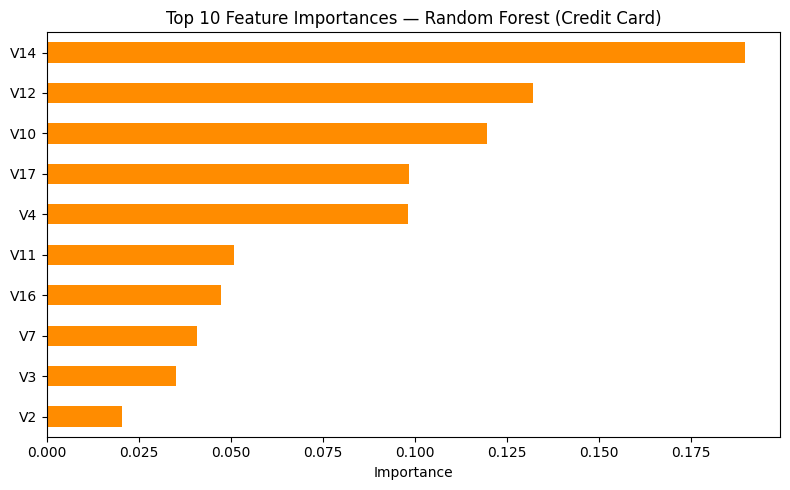

V14    0.189643
V12    0.132108
V10    0.119646
V17    0.098417
V4     0.098143
V11    0.050762
V16    0.047239
V7     0.040883
V3     0.034953
V2     0.020257
dtype: float64


In [8]:
importances_c = pd.Series(rf_c.feature_importances_, index=X_train_c.columns)
top10_c = importances_c.sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 5))
top10_c.sort_values().plot(kind='barh', color='darkorange')
plt.title('Top 10 Feature Importances — Random Forest (Credit Card)')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('../notebooks/feature_importance_credit.png', dpi=150, bbox_inches='tight')
plt.show()

print(top10_c)

In [9]:
# Sample test set for SHAP (TreeExplainer is fast, but sampling keeps plots readable)
sample_size = min(1000, len(X_test_f))
X_test_f_sample = X_test_f.sample(sample_size, random_state=RANDOM_STATE)

explainer_f = shap.TreeExplainer(rf_f)
shap_values_f = explainer_f.shap_values(X_test_f_sample)

# For binary classification, shap_values is a list [class_0, class_1] — we want class 1 (fraud)
shap_values_f_fraud = shap_values_f[1] if isinstance(shap_values_f, list) else shap_values_f

print("SHAP values computed for fraud model. Shape:", np.array(shap_values_f_fraud).shape)

SHAP values computed for fraud model. Shape: (1000, 196, 2)


In [ ]:
# Aggregate country_* SHAP contributions into one combined feature for readability
country_cols = [c for c in X_test_f_sample.columns if c.startswith('country_')]
non_country_cols = [c for c in X_test_f_sample.columns if not c.startswith('country_')]

# Sum SHAP values across all country dummies into one column
country_col_idx = [X_test_f_sample.columns.get_loc(c) for c in country_cols]
non_country_idx = [X_test_f_sample.columns.get_loc(c) for c in non_country_cols]

shap_country_agg = shap_values_f_fraud[:, country_col_idx].sum(axis=1, keepdims=True)
shap_agg = np.hstack([shap_values_f_fraud[:, non_country_idx], shap_country_agg])

X_display = X_test_f_sample[non_country_cols].copy()
X_display['country_combined'] = X_test_f_sample[country_cols].sum(axis=1)  # rough placeholder for display

shap.summary_plot(shap_agg, X_display, show=False)
plt.title('SHAP Summary — Fraud Data (country dummies aggregated)')
plt.tight_layout()
plt.savefig('../notebooks/shap_summary_fraud.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
sample_size_c = min(1000, len(X_test_c))
X_test_c_sample = X_test_c.sample(sample_size_c, random_state=RANDOM_STATE)

explainer_c = shap.TreeExplainer(rf_c)
shap_values_c = explainer_c.shap_values(X_test_c_sample)
shap_values_c_fraud = shap_values_c[1] if isinstance(shap_values_c, list) else shap_values_c

shap.summary_plot(shap_values_c_fraud, X_test_c_sample, show=False)
plt.title('SHAP Summary — Credit Card (Random Forest)')
plt.tight_layout()
plt.savefig('../notebooks/shap_summary_credit.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
y_prob_sample = rf_f.predict_proba(X_test_f_sample)[:, 1]
y_pred_sample = (y_prob_sample >= 0.5).astype(int)
y_true_sample = y_test_f.loc[X_test_f_sample.index]

results_df = pd.DataFrame({
    'y_true': y_true_sample.values,
    'y_pred': y_pred_sample,
    'y_prob': y_prob_sample
}, index=X_test_f_sample.index)

tp_idx = results_df[(results_df.y_true == 1) & (results_df.y_pred == 1)].index
fp_idx = results_df[(results_df.y_true == 0) & (results_df.y_pred == 1)].index
fn_idx = results_df[(results_df.y_true == 1) & (results_df.y_pred == 0)].index

print(f"True Positives available: {len(tp_idx)}")
print(f"False Positives available: {len(fp_idx)}")
print(f"False Negatives available: {len(fn_idx)}")

# Pick one of each
tp_example = tp_idx[0] if len(tp_idx) > 0 else None
fp_example = fp_idx[0] if len(fp_idx) > 0 else None
fn_example = fn_idx[0] if len(fn_idx) > 0 else None

print("\nSelected examples:")
print("TP index:", tp_example)
print("FP index:", fp_example)
print("FN index:", fn_example)

In [ ]:
# Get the positional index within X_test_f_sample for the chosen row
tp_pos = X_test_f_sample.index.get_loc(tp_example)

shap.force_plot(
    explainer_f.expected_value[1] if isinstance(explainer_f.expected_value, (list, np.ndarray)) else explainer_f.expected_value,
    shap_values_f_fraud[tp_pos],
    X_test_f_sample.iloc[tp_pos],
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — True Positive (prob={results_df.loc[tp_example, "y_prob"]:.3f})')
plt.tight_layout()
plt.savefig('../notebooks/shap_force_tp.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fp_pos = X_test_f_sample.index.get_loc(fp_example)

shap.force_plot(
    explainer_f.expected_value[1] if isinstance(explainer_f.expected_value, (list, np.ndarray)) else explainer_f.expected_value,
    shap_values_f_fraud[fp_pos],
    X_test_f_sample.iloc[fp_pos],
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — False Positive (prob={results_df.loc[fp_example, "y_prob"]:.3f})')
plt.tight_layout()
plt.savefig('../notebooks/shap_force_fp.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
fn_pos = X_test_f_sample.index.get_loc(fn_example)

shap.force_plot(
    explainer_f.expected_value[1] if isinstance(explainer_f.expected_value, (list, np.ndarray)) else explainer_f.expected_value,
    shap_values_f_fraud[fn_pos],
    X_test_f_sample.iloc[fn_pos],
    matplotlib=True,
    show=False
)
plt.title(f'SHAP Force Plot — False Negative (prob={results_df.loc[fn_example, "y_prob"]:.3f})')
plt.tight_layout()
plt.savefig('../notebooks/shap_force_fn.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
shap_importance = pd.Series(
    np.abs(shap_values_f_fraud).mean(axis=0),
    index=X_test_f_sample.columns
).sort_values(ascending=False)

comparison = pd.DataFrame({
    'Built-in Importance': importances_f,
    'Mean |SHAP value|': shap_importance
}).fillna(0)

comparison['Built-in Rank'] = comparison['Built-in Importance'].rank(ascending=False)
comparison['SHAP Rank'] = comparison['Mean |SHAP value|'].rank(ascending=False)

print(comparison.sort_values('SHAP Rank').head(10))